# Explore the dataset

### Installation:

- opt 1: Activate the conda environment and call `jupyter notebook notebooks/explore_data.ipynb`

- opt 2: Start vscode. Run `python -m ipykernel install --user --name=hrmelt` to link the conda environment to juypter. Then, select hrmelt

### Visualize the study area

In [2]:
import os

In [3]:
from ipyleaflet import Map, Marker, basemaps, basemap_to_tiles

center = (66.35, 321.80) # Helheim Glacier N-E coordinates 
marker = Marker(name='helheim-glacier', location=center)

zoom = 3
basemap = basemap_to_tiles(basemaps.Gaode.Satellite)
# basemap = basemap_to_tiles(basemaps.OpenTopoMap)
m = Map(basemap=basemap, center=center, zoom=zoom)
m.add_layer(marker)

m

Map(center=[66.35, 321.8], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

### Visualize prediction target: Surface Meltwater

In [4]:
import yaml

from localtileserver import get_leaflet_tile_layer, TileClient
from ipyleaflet import LayersControl
from pathlib import Path

import os
# Uncomment this line with the path to your installation of proj, if you get the error "Cannot find proj.db"
os.environ['PROJ_LIB'] = '/home/bjoern/miniconda3/envs/hrmelt/lib/python3.9/site-packages/osgeo/proj'

# First, create a tile server from sample local raster file
dataroot = Path('../data/raw/Helheim_data/sample//')
melt = 'SAR/S1X/HH_PercentMelt/2018_09_10.tif'
mar = 'MAR/MARv3.12/WA1/2018_09_10.tif'
pmw = 'PMW/2018_09_10.tif'
# modis_b1 = 'MODIS/MOD09GA_b01/2018_09_10.tif'
# modis_b2 = 'MODIS/MOD09Ga_b02/2018_09_10.tif'
landmask = 'GIMP_Mask/landMask_100m.tif'
dem = 'GrIMP_DEM/dem_100m.tif'

client = TileClient(str(dataroot/melt))
t = get_leaflet_tile_layer(client)
m = Map(center=client.center(), zoom=client.default_zoom)
m.add_layer(t)

m.add_control(LayersControl())
m


/Users/bjoern/miniforge3/envs/hrmelt2/lib/python3.9/site-packages/localtileserver/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Map(center=[66.24812800289624, -38.059292295323345], controls=(ZoomControl(options=['position', 'zoom_in_text'…

### Visualize the full in- and output data stack: PMW, MAR, DEM, (MODIS), --> Surface Melt

In [5]:
from localtileserver import get_leaflet_tile_layer, TileClient
from ipyleaflet import Map

t_mar = get_leaflet_tile_layer(str(dataroot/mar), name='mar')
# t_modis = get_leaflet_tile_layer(str(dataroot/modis_b1), name='modis')
t_melt = get_leaflet_tile_layer(str(dataroot/melt), name='melt')
t_pmw = get_leaflet_tile_layer(str(dataroot/pmw), name='pmw')
t_landmask = get_leaflet_tile_layer(str(dataroot/landmask), name='landmask')
t_dem = get_leaflet_tile_layer(str(dataroot/dem), name='dem')

m = Map(center=center, zoom=8)
m.add_layer(t_mar)
# m.add_layer(t_modis)
m.add_layer(t_melt)
m.add_layer(t_pmw)
m.add_layer(t_landmask)
m.add_layer(t_dem)
m.add_control(LayersControl())

m

Map(center=[66.35, 321.8], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

#### The difference in spatial resolution between MAR, PMW, and Surface Meltwater is very large

In [6]:
from localtileserver import get_leaflet_tile_layer
from ipyleaflet import Map, ScaleControl, FullScreenControl, SplitMapControl

m = Map(basemap=basemap, center=center, zoom=8)
l = get_leaflet_tile_layer(str(dataroot/mar))
r = get_leaflet_tile_layer(str(dataroot/melt))
control = SplitMapControl(left_layer=l, right_layer=r)
m.add_control(control)

m.add_control(ScaleControl(position='bottomleft'))
m.add_control(FullScreenControl())
m

Map(center=[66.35, 321.8], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

### Load dataset

Double-check that cfg['data_root'] and cfg['path_*'] points to correct paths:

In [13]:
import yaml
# for all data: cfg = yaml.safe_load(open('../runs/unet_smp/data_v1_4/config/config.yaml', 'r'))
cfg = yaml.safe_load(open('../runs/unet/sample/config/config.yaml', 'r'))
cfg['data_root'] = '../' + cfg['data_root'] 
cfg['path_train_split_csv'] = '../' + cfg['path_train_split_csv']# adjust for relative path of this notebook.
cfg['path_val_split_csv'] = '../' + cfg['path_val_split_csv']# adjust for relative path of this notebook.
cfg['path_test_split_csv'] = '../' + cfg['path_test_split_csv']# adjust for relative path of this notebook.
print(f"data_root: {cfg['data_root']} '\npath_melt {cfg['path_melt']}")

data_root: .././data/ '
path_melt raw/Helheim_data/sample/SAR/S1X/HH_PercentMelt/


Initialize the dataloader. This may take 2-10min for the full dataset as complete entries are found and incomplete entries are being rejected.

In [19]:
from hrmelt.dataset import HRMeltDataset
cfg['img_size'] = (512, 512)
cfg['normalize_inputs'] = False
print('Data inputs: ', cfg['in_keys'])
cfg['split_cfg'] = 'csv'

dataset = HRMeltDataset(cfg, split='train', verbose=False)

print('Number of complete entries in dataset: ',len(dataset))

inputs, targets, targets_mask, meta = dataset.__getitem__(idx=0)

Data inputs:  ['pmw', 'mar_wa1']
Number of complete entries in dataset:  1


In [21]:
dataset.data

[{'pmw': PosixPath('../data/raw/Helheim_data/sample/PMW/2018_04_25.tif'),
  'mar_wa1': PosixPath('../data/raw/Helheim_data/sample/MAR/MARv3.12/WA1/2018_04_25.tif'),
  'melt': PosixPath('../data/raw/Helheim_data/sample/SAR/S1X/HH_PercentMelt/2018_04_25.tif')}]

### Plot random crops from first data sample:

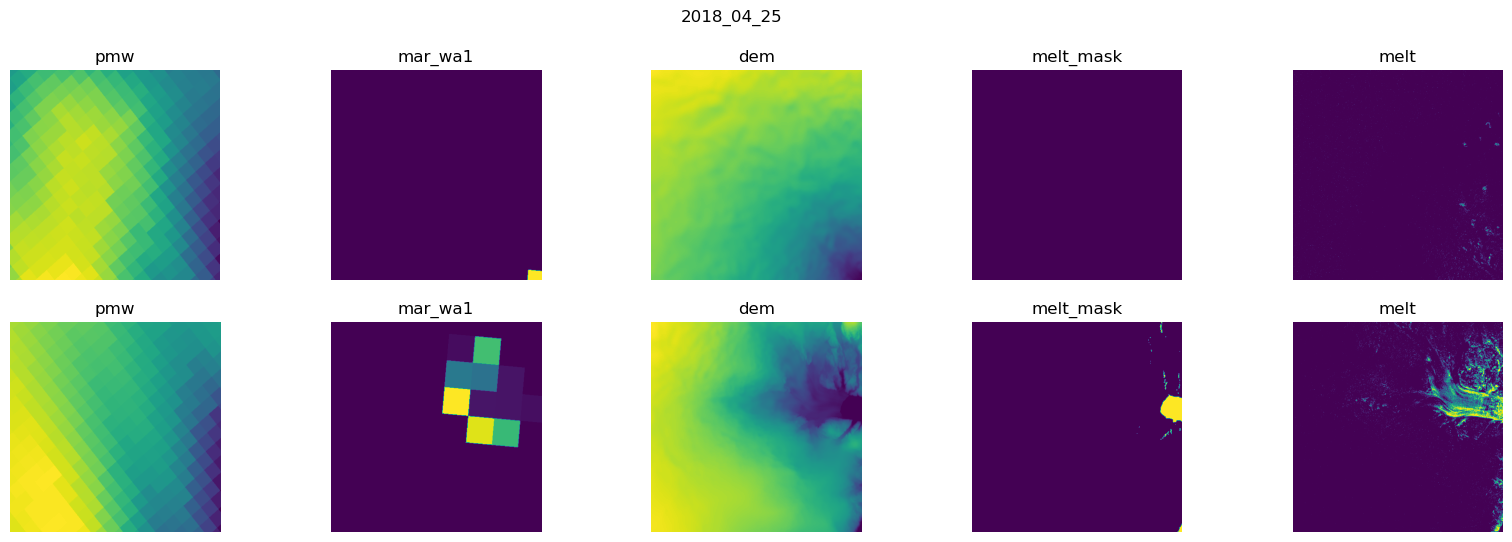

In [23]:
# %matplotlib notebook

import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_n_img_chips(dataset, n_imgs=2, data_idx=0, verbose=False):
    keys = dataset.cfg['in_keys'] + dataset.cfg['in_keys_static'] + ['melt_mask', 'melt']
    dataset.verbose=verbose

    plt.figure(figsize=(20,3*n_imgs))
    columns = len(dataset.keys)
    n_plots = n_imgs * columns
    for idx in range(n_imgs):
        # Retrieve new image crop
        inputs, targets, targets_mask, meta = dataset.__getitem__(idx=data_idx)
        imgs = torch.cat((inputs, targets_mask, targets),dim=0)
        imgs_np = imgs.cpu().numpy()

        for i, img in enumerate(imgs_np):
            plt.subplot(n_imgs, columns, idx*columns + i + 1)
            plt.imshow(img)
            plt.title(dataset.keys[i])
            plt.axis('off')
        plt.suptitle(Path(meta['path_melt']).stem)
    dataset.verbose=False
    
plot_n_img_chips(dataset=dataset, n_imgs=2, data_idx=0)

### Compute mean and variance per modality across dataset

Stats of cropped tile before scale and normalize.
pmw min, max, mean, std:   	(np.float32(166.32), np.float32(206.59), np.float32(183.11882), np.float32(10.270848), 'float32')
mar_wa1 min, max, mean, std:	(np.float32(0.0), np.float32(0.042492926), np.float32(0.00049248204), np.float32(0.004256538), 'float32')
dem min, max, mean, std:   	(np.float32(45.285503), np.float32(230.98541), np.float32(47.160564), np.float32(6.3534126), 'float32')
melt min, max, mean, std:   	(np.float32(0.0), np.float32(1.0), np.float64(0.443313356703316), np.float64(0.4162846731958445), 'float32') after masking
landmask min, max, mean, std:	(np.float32(-1.0), np.float32(1.0), np.float32(-0.96681213), np.float32(0.25548843), 'float32')


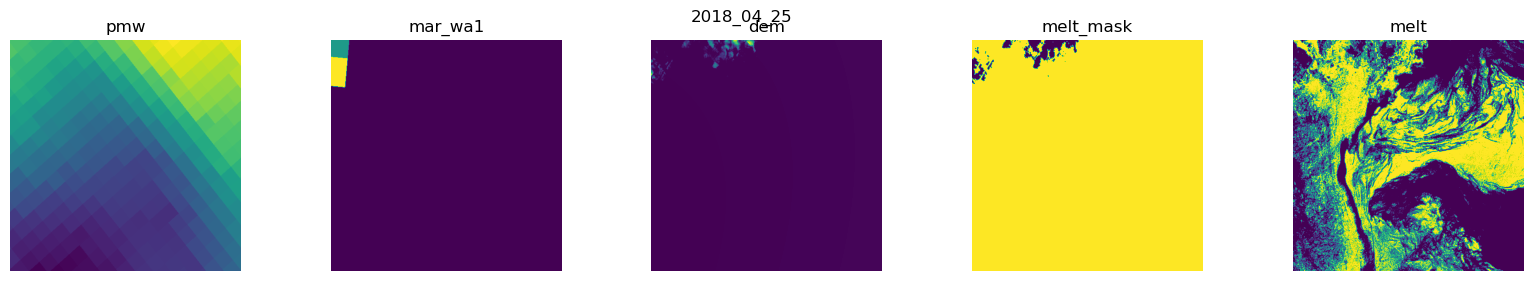

In [25]:
n_samples = min(len(dataset), 10)
for i in range(n_samples):
    plot_n_img_chips(dataset=dataset, n_imgs=1, data_idx=i, verbose=True)
    plt.show()

1
Stats of cropped tile before scale and normalize.
pmw min, max, mean, std:   	(np.float32(136.66), np.float32(221.42), np.float32(200.98544), np.float32(13.658783), 'float32')
mar_wa1 min, max, mean, std:	(np.float32(0.0), np.float32(0.07152628), np.float32(0.0031587237), np.float32(0.010946615), 'float32')
dem min, max, mean, std:   	(np.float32(44.359737), np.float32(3439.392), np.float32(1175.0969), np.float32(993.8532), 'float32')
melt min, max, mean, std:   	(np.float32(0.0), np.float32(1.0), np.float64(0.12068861520076182), np.float64(0.2850083018348556), 'float32') after masking
landmask min, max, mean, std:	(np.float32(-1.0), np.float32(1.0), np.float32(0.43120486), np.float32(0.9022539), 'float32')


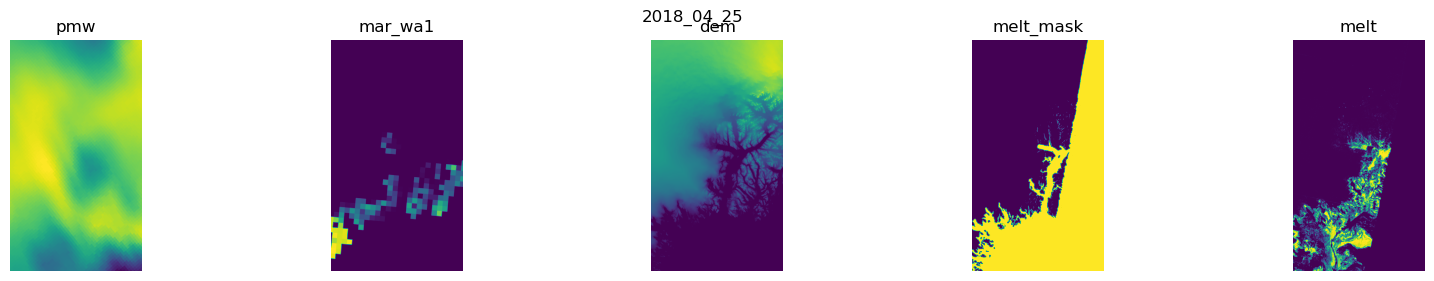

In [28]:
print(len(dataset.data))

dataset.cfg['img_size'] = (2863, 1633)
for idx in range(min(len(dataset), 3)):
    plot_n_img_chips(dataset=dataset, n_imgs=1, data_idx=idx, verbose=True)

Stats of cropped tile before scale and normalize.
pmw min, max, mean, std:   	(np.float32(145.86), np.float32(249.48), np.float32(196.08876), np.float32(30.393412), 'float32')
mar_wa1 min, max, mean, std:	(np.float32(0.0), np.float32(0.089045964), np.float32(0.0039093387), np.float32(0.013676028), 'float32')
dem min, max, mean, std:   	(np.float32(44.359737), np.float32(3439.392), np.float32(1175.0969), np.float32(993.8532), 'float32')
melt min, max, mean, std:   	(np.float32(0.0), np.float32(1.0), np.float64(0.46208503569571024), np.float64(0.4700593824529751), 'float32') after masking
landmask min, max, mean, std:	(np.float32(-1.0), np.float32(1.0), np.float32(0.43120486), np.float32(0.9022539), 'float32')


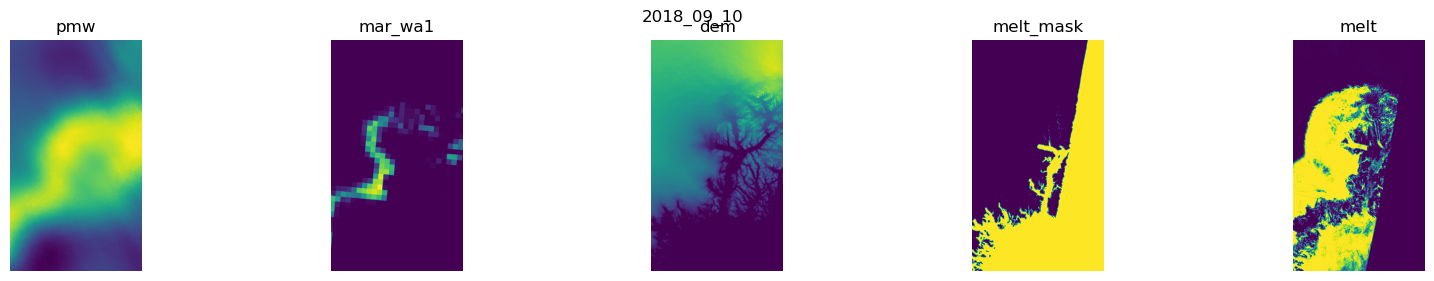

In [30]:
# Plots from the validation set:
valset = HRMeltDataset(cfg, split='val', verbose=False)
valset.cfg['img_size'] = (2863, 1633)
for idx in range(min(len(valset), 3)):
    plot_n_img_chips(dataset=valset, n_imgs=1, data_idx=idx, verbose=True)

Calculate mean and standard deviation across the full dataset. This may take 5-15min.

In [23]:
from tqdm import tqdm
from hrmelt.utils.utils import calculate_means_stds_across_dataset

dataset.verbose = False 
dataset.cfg['img_size'] = (2863, 1633)
# Calculates mean and standard deviation across the dataset using all pixels
#  todo: calculate the mean only on valid pixels
means, stds = calculate_means_stds_across_dataset(dataset, verbose=False)

100%|██████████| 413/413 [21:57<00:00,  3.19s/it]

mean_pmw: 205.20697021484375
mean_mar_wa1: 0.0057306960225105286
mean_time_interpolate_sar: 0.21418656408786774
mean_dem: 1175.09423828125
mean_melt_mask: 0.6308506727218628
mean_melt: 0.1849832534790039
std_pmw: 26.367090225219727
std_mar_wa1: 0.008627712726593018
std_time_interpolate_sar: 0.32557857036590576
std_dem: 993.8513793945312
std_melt_mask: 0.4244263172149658
std_melt: 0.30067816376686096



### The ratio of invalid / (invalid+valid) pixels over the dataset is about 50%:

In [26]:
for (key, mean) in zip(dataset.keys, means):
    if key == 'melt_mask':
        print(f'Percentage of masked area in SAR: {mean*100.}%')

Percentage of masked area in SAR: 63.08506727218628%


### Calculate histogram of surface meltwater values

In [4]:
# %matplotlib notebook

from pathlib import Path
import matplotlib.pyplot as plt

In [5]:
%load_ext autoreload
%autoreload 2
    
import importlib
import hrmelt.utils.utils as utils
importlib.reload(utils) # automatically reload library

import time
from tqdm import tqdm
from torch.utils.data import DataLoader
# from IPython.core.debugger import set_trace

from hrmelt.utils.utils import calculate_target_histogram 

# Wrap dataset into dataloader for parallelization via batch_size
dataset.cfg['img_size'] = (2863, 1633)
dataloader = DataLoader(dataset, batch_size=1, num_workers=2,shuffle=False)
# fig.show()
# fig.close()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
hist = calculate_target_histogram(dataloader,n_bins=11)

389it [30:52,  4.76s/it]


In [35]:
import torch
print('number of bars: ', len(torch.arange(len(hist))))
print('Cutoff-values:', torch.linspace(0,1,len(hist)))
print('Values: ', hist)

number of bars:  11
Cutoff-values: tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])
Values:  tensor([0.6539, 0.0182, 0.0118, 0.0096, 0.0085, 0.0080, 0.0079, 0.0081, 0.0088,
        0.0109, 0.2543])


In [36]:
print(f'Share of valid melt {torch.sum(hist[1:]) * 100:0.2f}% and no-melt {hist[0]*100:0.2f}% pixels.')

Share of valid melt 34.61% and no-melt 65.39% pixels.


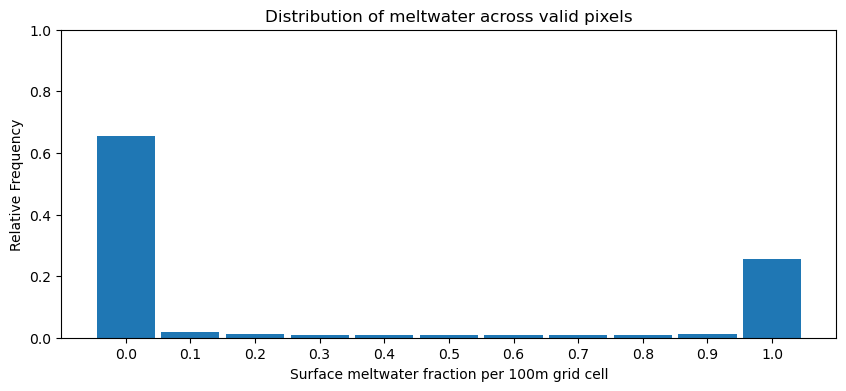

In [38]:
dir_figures = '../references/figures/data_exploration/'
#def plot_surface_meltwater_histogram(hist, 
#    dir_figures='../references/figures/data_exploration/'):
"""
Will plot and save a given histogram
"""
hist_xaxis = torch.linspace(0,1,len(hist))
width = hist_xaxis[1]-hist_xaxis[0]
width = width * 0.9
#plt.bar(torch.arange(len(hist)), hist)
plt.figure(figsize=(10,4))
plt.bar(hist_xaxis, hist, width=width)
# todo: correct the xticks in the plot
# plt.bar(torch.arange(n_bins), hist, hist_bin_values[:-1])
# plt.xticks(hist_bin_values[:-1].cpu().numpy())
plt.xticks(hist_xaxis.cpu().numpy())
plt.gca().xaxis.set_major_formatter('{x:.1f}')
plt.gca().set_ylim((0,1))

plt.xlabel("Surface meltwater fraction per 100m grid cell")
plt.ylabel("Relative Frequency")
# plt.yscale('log', base=10)
plt.title("Distribution of meltwater across valid pixels")
Path(dir_figures).mkdir(parents=True, exist_ok=True)
plt.savefig(dir_figures + 'histogram_meltwater.png')
plt.show()
plt.close()

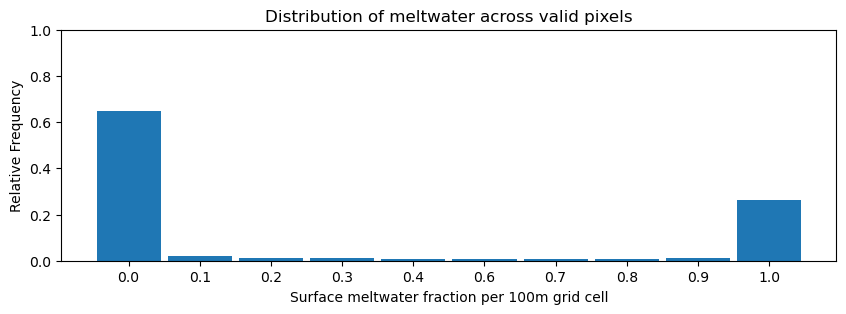

In [46]:
dir_figures = '../references/figures/data_exploration/'
#def plot_surface_meltwater_histogram(hist, 
#    dir_figures='../references/figures/data_exploration/'):
"""
Will plot and save a given histogram
"""
hist_xaxis = torch.linspace(0,1,len(hist))
width = hist_xaxis[1]-hist_xaxis[0]
width = width * 0.9
#plt.bar(torch.arange(len(hist)), hist)
plt.figure(figsize=(10,3))
plt.bar(hist_xaxis, hist, width=width)
# todo: correct the xticks in the plot
# plt.bar(torch.arange(n_bins), hist, hist_bin_values[:-1])
# plt.xticks(hist_bin_values[:-1].cpu().numpy())
plt.xticks(hist_xaxis.cpu().numpy())
plt.gca().xaxis.set_major_formatter('{x:.1f}')
plt.gca().set_ylim((0,1))

plt.xlabel("Surface meltwater fraction per 100m grid cell")
plt.ylabel("Relative Frequency")
# plt.yscale('log', base=10)
plt.title("Distribution of meltwater across valid pixels")
Path(dir_figures).mkdir(parents=True, exist_ok=True)
plt.savefig(dir_figures + 'histogram_meltwater.png')
plt.show()
plt.close()

The dataset seems slightly only biased towards pixels with meltwater. However, there is very little support for meltwater values in between the extremes.

Measure imbalance between two classes: melt- and no meltwater:

In [29]:
hist = calculate_target_histogram(dataloader, n_bins=2, binarize_data=True)
print(f'The dataset has {hist[0]}% zero and {hist[1]}% non-zero pixels.')

413it [36:31,  5.31s/it]

The dataset has 0.5901684761047363% zero and 0.4098314940929413% non-zero pixels.
